In [4]:
import numpy as np
import scipy.io
import mne
import matplotlib.pyplot as plt
import os
from mne.preprocessing import find_bad_channels_lof
# Task 1: preprocessing + visualization + band-power analysis
# Data convention in this notebook: X uses (N_segments, N_channels, N_timepoints).

def load_s2_subject(file_path):
    """Load Subject-2 EEG segments from S2.mat.

    Expected keys:
    - X: (N_segments, N_channels, N_timepoints)
    - y: (N_segments, 1) or (N_segments,)
    - fs: scalar sampling rate
    """
    mat = scipy.io.loadmat(file_path, squeeze_me=False, struct_as_record=False)
    required = {'X', 'y', 'fs'}
    missing = required - set(mat.keys())
    if missing:
        raise KeyError(f"Missing keys in MAT file: {sorted(missing)}")

    X = np.asarray(mat['X'], dtype=np.float32)
    y = np.asarray(mat['y']).reshape(-1)
    fs = float(np.asarray(mat['fs']).squeeze())

    if X.ndim != 3:
        raise ValueError(f"X must be 3D (N, C, T), got shape {X.shape}")
    if X.shape[0] != y.shape[0]:
        raise ValueError(f"X and y size mismatch: {X.shape[0]} vs {y.shape[0]}")

    # Convert labels to binary 0/1 (assignment format: 0=left, 1=right)
    uniq = np.unique(y)
    if len(uniq) != 2:
        raise ValueError(f"AAD is binary classification, got labels: {uniq}")
    y_map = {uniq[0]: 0, uniq[1]: 1}
    y_bin = np.vectorize(y_map.get)(y).astype(np.int64)

    return X, y_bin, fs


def _build_64ch_info(sfreq):
    montage = mne.channels.make_standard_montage('biosemi64')
    ch_names = montage.ch_names[:64]
    info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types='eeg')
    info.set_montage(montage)
    return info


def run_task1_preprocessing(file_path='S2.mat', random_state=42):
    """Task 1: preprocess + visualization + reshape.

    Returns:
    - X_prep: (N_segments, 64, T)
    - y: (N_segments,)
    - epochs: MNE EpochsArray
    - info: MNE info
    - sfreq: sampling rate
    """
    X, y, sfreq = load_s2_subject(file_path)

    # (a) data inspection
    n_seg, n_ch, n_t = X.shape
    print(f"Sampling rate: {sfreq} Hz")
    print(f"Total channels: {n_ch}")
    print(f"Time points/segment: {n_t}")
    print(f"Total segments: {n_seg}")

    # (b) keep first 64 scalp channels
    if n_ch < 64:
        raise ValueError(f"Need >=64 channels, got {n_ch}")
    X64 = X[:, :64, :]

    # Build MNE RawArray from concatenated segments
    info = _build_64ch_info(sfreq)
    # Concatenate all segments on the time axis for filtering in a single Raw object.
    data_concat = X64.transpose(1, 0, 2).reshape(64, -1)
    raw = mne.io.RawArray(data_concat.copy(), info, verbose='ERROR')
    raw_before = raw.copy()


    # raw 已经创建好（64通道 + montage）
    bads, scores = find_bad_channels_lof(raw, n_neighbors=20, threshold=1.5, return_scores=True)
    raw.info['bads'] = bads
    print('Detected bad channels:', bads)

    # pick only EEG channels, excluding MEG.
    raw_eeg = raw.copy().pick(picks="eeg")
    # visualize the EEG data
    print("Raw EEG data (after bad channel marking):")
    raw_eeg.plot(duration=5,n_channels=1)
    print(raw)
    print(raw.info)
    # (c) filtering: 4-40Hz bandpass + 50Hz notch
    raw.filter(l_freq=4.0, h_freq=40.0, fir_design='firwin', verbose='ERROR')
    raw.notch_filter(freqs=50.0, verbose='ERROR')

    # plot one representative 1-second segment on 10 random channels
    rng = np.random.default_rng(random_state)
    picks = rng.choice(64, size=10, replace=False)
    seg_id = min(n_seg // 2, n_seg - 1)
    start = seg_id * n_t
    stop = start + n_t

    before = raw_before.get_data(picks=picks, start=start, stop=stop)
    after = raw.get_data(picks=picks, start=start, stop=stop)
    t = np.arange(n_t) / sfreq

    save_dir = 'pic'
    os.makedirs(save_dir, exist_ok=True)

    # Visualization preparation
    before_center = before - before.mean(axis=1, keepdims=True)
    after_center = after - after.mean(axis=1, keepdims=True)
    before_norm = before_center / (before_center.std(axis=1, keepdims=True) + 1e-8)
    after_norm = after_center / (after_center.std(axis=1, keepdims=True) + 1e-8)

    # Figure 1: centered amplitude (10 channels)
    plt.figure(figsize=(12, 6))
    amp_step = np.percentile(np.abs(before_center), 95) * 2.2 + 1e-6
    for i in range(10):
        offset = i * amp_step
        plt.plot(t, before_center[i] + offset, color='#d35400', alpha=0.85, lw=1.0)
        plt.plot(t, after_center[i] + offset, color='#2980b9', alpha=0.85, lw=1.0)
    plt.title('Task 1(c) Figure 1: Centered Amplitude (10 channels)')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude (centered) + offset')
    plt.tight_layout()
    fig1_path = os.path.join(save_dir, 'task1c_figure1_centered.png')
    plt.savefig(fig1_path, dpi=200, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fig1_path}')

    # Figure 2: normalized waveforms (10 channels)
    plt.figure(figsize=(12, 6))
    norm_step = 6.0
    for i in range(10):
        offset = i * norm_step
        plt.plot(t, before_norm[i] + offset, color='#d35400', alpha=0.85, lw=1.0)
        plt.plot(t, after_norm[i] + offset, color='#2980b9', alpha=0.85, lw=1.0)
    plt.title('Task 1(c) Figure 2: Normalized Waveforms (10 channels)')
    plt.xlabel('Time (s)')
    plt.ylabel('Normalized amplitude + offset')
    plt.tight_layout()
    fig2_path = os.path.join(save_dir, 'task1c_figure2_normalized.png')
    plt.savefig(fig2_path, dpi=200, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fig2_path}')

    # Figure 3: single-channel zoom (before vs after)
    ch_zoom = 0
    plt.figure(figsize=(12, 4))
    plt.plot(t, before_center[ch_zoom], color='#d35400', lw=1.5, label='Before filter')
    plt.plot(t, after_center[ch_zoom], color='#2980b9', lw=1.5, label='After filter')
    plt.title(f'Task 1(c) Figure 3: Single-Channel Zoom (channel index: {picks[ch_zoom]})')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude (centered)')
    plt.legend()
    plt.tight_layout()
    fig3_path = os.path.join(save_dir, 'task1c_figure3_single_channel_zoom.png')
    plt.savefig(fig3_path, dpi=220, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fig3_path}')

    # (d) average re-reference
    raw.set_eeg_reference('average', projection=False, verbose='ERROR')

    # (e) reshape back to (N, C, T)
    # Recover back to assignment format: (N_segments, 64, N_timepoints).
    data_after_ref = raw.get_data().reshape(64, n_seg, n_t).transpose(1, 0, 2).astype(np.float32)
    epochs = mne.EpochsArray(data_after_ref, info=raw.info.copy(), verbose='ERROR')

    print(f"Final preprocessed shape: {data_after_ref.shape}")
    print(f"Label distribution (0/1): {np.bincount(y)}")
    return data_after_ref, y, epochs, raw.info, sfreq


def run_task1_feature_analysis(X_prep, info, sfreq):
    """Task 1(3): compute channel-wise average band power and draw topomaps."""
    if X_prep.ndim != 3:
        raise ValueError(f"X_prep must be (N, C, T), got {X_prep.shape}")

    bands = {
        'Theta (4-8 Hz)': (4, 8),
        'Alpha (8-13 Hz)': (8, 13),
        'Beta (13-30 Hz)': (13, 30),
    }

    n_seg, n_ch, n_t = X_prep.shape
    freqs = np.fft.rfftfreq(n_t, d=1.0 / sfreq)
    # FFT-based PSD estimate for each segment/channel.
    psd = (np.abs(np.fft.rfft(X_prep, axis=-1)) ** 2) / n_t  # (N, C, F)
    psd_mean = psd.mean(axis=0)  # (C, F), average over segments

    band_power = {}
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, (band_name, (f_lo, f_hi)) in zip(axes, bands.items()):
        mask = (freqs >= f_lo) & (freqs <= f_hi)
        bp = psd_mean[:, mask].mean(axis=1)
        band_power[band_name] = bp

        mne.viz.plot_topomap(bp, info, axes=ax, show=False, cmap='viridis', contours=6)
        ax.set_title(band_name)

    plt.suptitle('Task 1(3): Channel-wise Average Band Power Topomaps')
    plt.tight_layout()
    plt.show()

    return band_power






Sampling rate: 200.0 Hz
Total channels: 66
Time points/segment: 200
Total segments: 3000
LOF: Detected bad channel(s): ['FT7']
Detected bad channels: ['FT7']
Raw EEG data (after bad channel marking):
Using matplotlib as 2D backend.


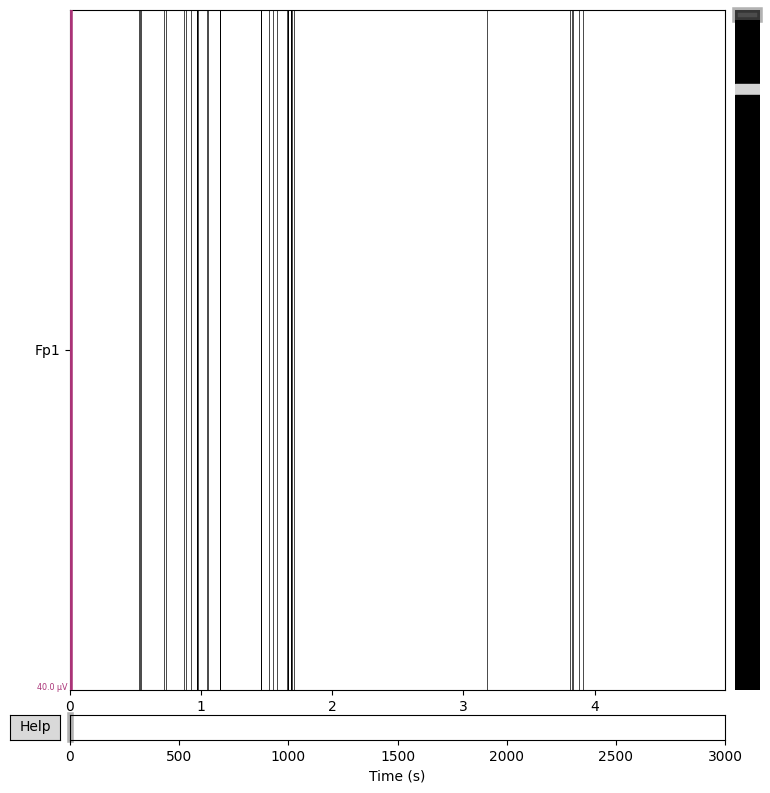

<RawArray | 64 x 600000 (3000.0 s), ~293.1 MiB, data loaded>
<Info | 9 non-empty values
 bads: 1 items (FT7)
 ch_names: Fp1, AF7, AF3, F1, F3, F5, F7, FT7, FC5, FC3, FC1, C1, C3, C5, ...
 chs: 64 EEG
 custom_ref_applied: False
 dig: 67 items (3 Cardinal, 64 EEG)
 highpass: 0.0 Hz
 lowpass: 100.0 Hz
 meas_date: unspecified
 nchan: 64
 projs: []
 sfreq: 200.0 Hz
>


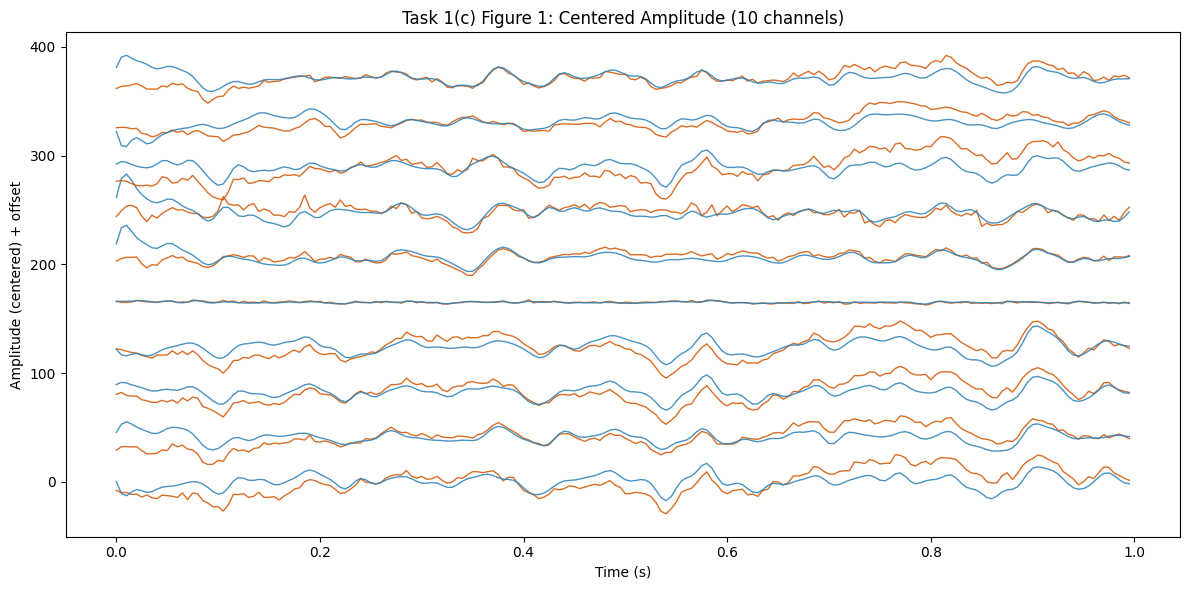

Saved: pic/task1c_figure1_centered.png


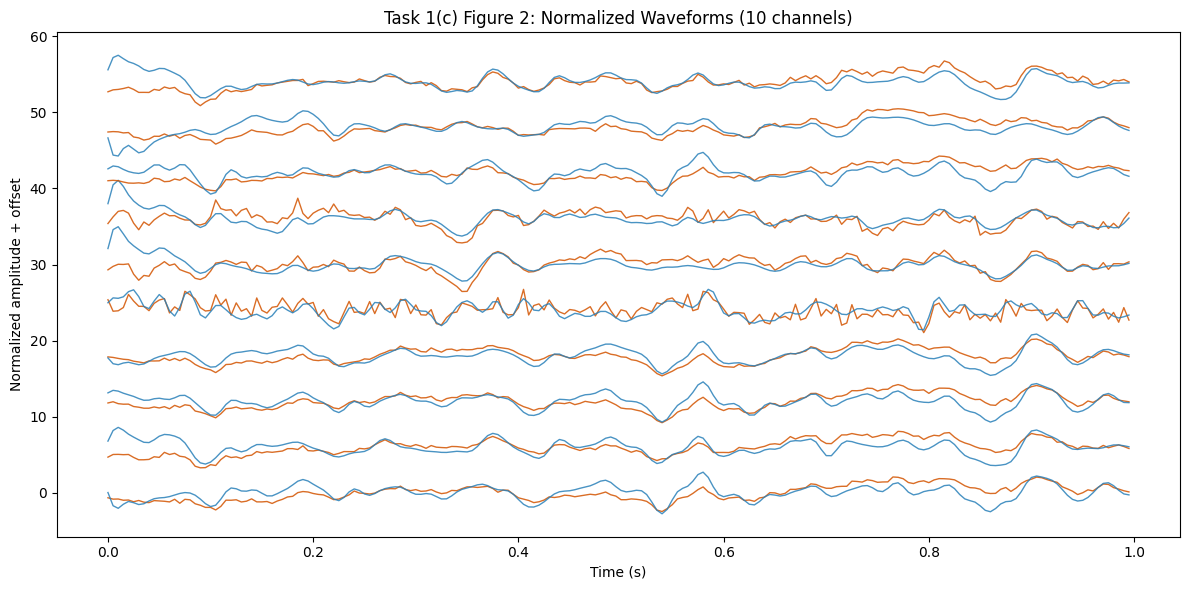

Saved: pic/task1c_figure2_normalized.png


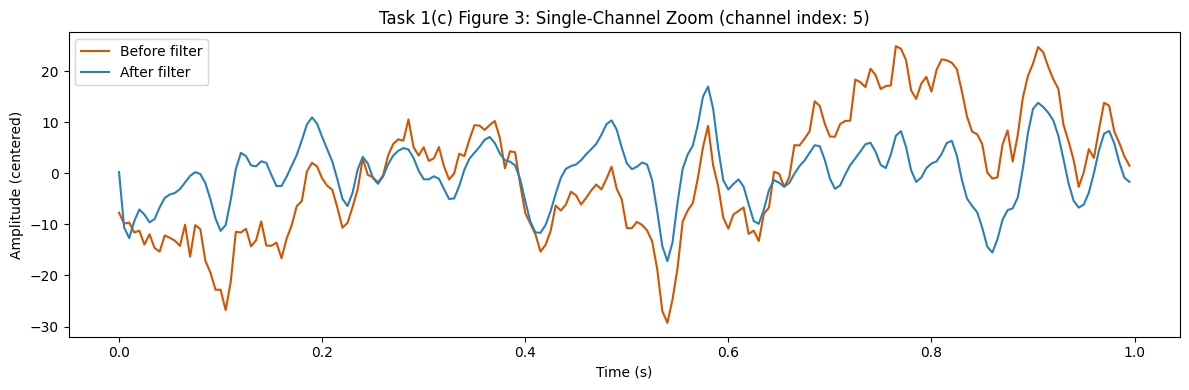

Saved: pic/task1c_figure3_single_channel_zoom.png
Final preprocessed shape: (3000, 64, 200)
Label distribution (0/1): [1450 1550]


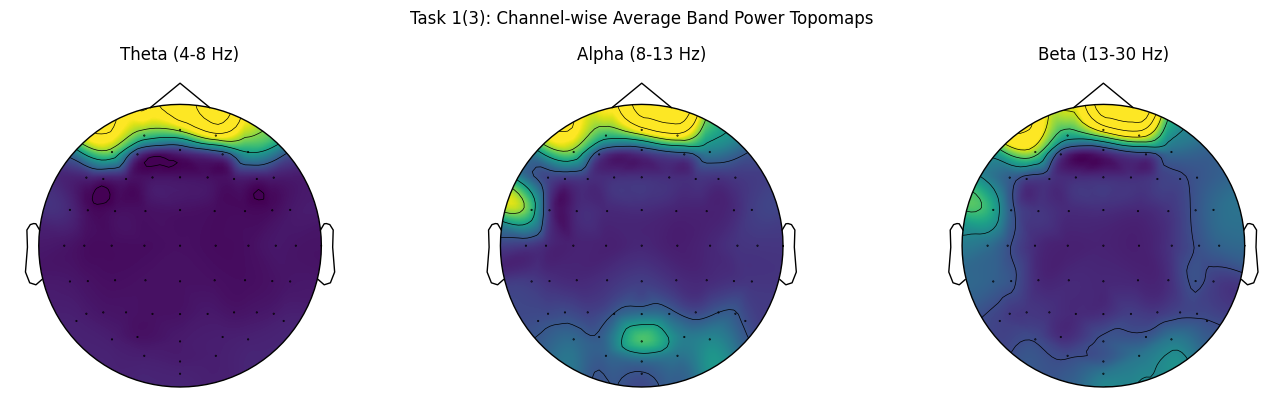

Task 1 done.
X_prep shape: (3000, 64, 200)
y shape: (3000,)


In [5]:
# Task 1 execution
# Output: preprocessed EEG, labels, and Task 1 visualizations
X_prep, y, epochs, info, sfreq = run_task1_preprocessing('S2.mat', random_state=42)
band_power = run_task1_feature_analysis(X_prep, info, sfreq)


print('Task 1 done.')
print('X_prep shape:', X_prep.shape)
print('y shape:', y.shape)

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from mne.decoding import CSP
from scipy.signal import butter, sosfiltfilt
import numpy as np
import time


def _bandpass_epochs(X, sfreq, f_low, f_high, order=4):
    sos = butter(order, [f_low, f_high], btype='bandpass', fs=sfreq, output='sos')
    return sosfiltfilt(sos, X, axis=-1)


def _extract_filterbank_csp_features(X_train, y_train, X_eval, sfreq, n_csp=4, bands=None):
    if bands is None:
        bands = [
            (4, 8), (8, 12), (12, 16), (16, 20),
            (20, 24), (24, 28), (28, 32), (32, 36), (36, 40),
        ]

    train_feats = []
    eval_feats = []
    csp_models = []

    for (f_low, f_high) in bands:
        Xtr_b = _bandpass_epochs(X_train, sfreq, f_low, f_high)
        Xev_b = _bandpass_epochs(X_eval, sfreq, f_low, f_high)

        csp = CSP(
            n_components=n_csp,
            reg='oas',
            log=True,
            norm_trace=False,
            transform_into='average_power',
        )
        csp.fit(Xtr_b, y_train)
        train_feats.append(csp.transform(Xtr_b))
        eval_feats.append(csp.transform(Xev_b))
        csp_models.append(csp)

    X_train_feat = np.concatenate(train_feats, axis=1)
    X_eval_feat = np.concatenate(eval_feats, axis=1)
    return X_train_feat, X_eval_feat, csp_models, bands


def _param_grid_for_kernel(kernel):
    if kernel == 'linear':
        return [{'C': c, 'class_weight': cw} for c in [0.1, 0.3, 1.0, 3.0, 10.0] for cw in [None, 'balanced']]
    if kernel == 'rbf':
        return [{'C': c, 'gamma': g, 'class_weight': cw}
                for c in [0.1, 0.3, 1.0, 3.0, 10.0]
                for g in ['scale', 1e-3, 3e-3, 1e-2]
                for cw in [None, 'balanced']]
    if kernel == 'poly':
        return [{'C': c, 'degree': d, 'gamma': g, 'class_weight': cw}
                for c in [0.3, 1.0, 3.0]
                for d in [2, 3]
                for g in ['scale', 1e-2]
                for cw in [None, 'balanced']]
    if kernel == 'sigmoid':
        return [{'C': c, 'gamma': g, 'class_weight': cw}
                for c in [0.3, 1.0, 3.0]
                for g in ['scale', 1e-2]
                for cw in [None, 'balanced']]
    return [{}]


def _fit_eval_on_val(X_train, y_train, X_val, y_val, kernel, show_progress=True):
    best_model = None
    best_val_acc = -1.0
    best_params = None

    grid = _param_grid_for_kernel(kernel)
    total = len(grid)

    for i, params in enumerate(grid, start=1):
        model = SVC(kernel=kernel, **params)
        model.fit(X_train, y_train)
        pred = model.predict(X_val)
        val_acc = accuracy_score(y_val, pred)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model = model
            best_params = params

        if show_progress:
            print(f"    - {kernel} param {i}/{total}: {params} -> val_acc={val_acc:.4f}")

    return best_model, best_val_acc, best_params


def run_task2_svm(
    X_prep,
    y,
    test_size=0.2,
    val_size=0.2,
    random_state=42,
    show_progress=True,
    sfreq=200.0,
    n_csp=4,
    k_best=16,
):
    """Task 2: Frequency-domain features -> CSP -> SVM (val tuning, one-shot test)."""
    if X_prep.ndim != 3:
        raise ValueError(f"X_prep must be (N, C, T), got {X_prep.shape}")

    # 1) Outer split: train_val / test (test untouched for final evaluation)
    X_trainval_raw, X_test_raw, y_trainval, y_test = train_test_split(
        X_prep, y, test_size=test_size, random_state=random_state, stratify=y,
    )

    # 2) Inner split: train / val for model selection
    X_train_raw, X_val_raw, y_train, y_val = train_test_split(
        X_trainval_raw, y_trainval, test_size=val_size, random_state=random_state, stratify=y_trainval,
    )

    if show_progress:
        print('[Task2] VERSION: v2 (val tuning + one-shot test)')
        print(f"[Task2] Raw train/val/test: {X_train_raw.shape} / {X_val_raw.shape} / {X_test_raw.shape}")
        print('[Task2] Extracting filter-bank CSP features ...')

    # 3) FBCSP feature extraction
    X_train_feat, X_val_feat, csp_models, bands = _extract_filterbank_csp_features(
        X_train_raw, y_train, X_val_raw, sfreq=sfreq, n_csp=n_csp
    )

    # For final one-shot test, transform test using same train-fitted CSPs
    test_feats = []
    for (f_low, f_high), csp in zip(bands, csp_models):
        Xte_b = _bandpass_epochs(X_test_raw, sfreq, f_low, f_high)
        test_feats.append(csp.transform(Xte_b))
    X_test_feat = np.concatenate(test_feats, axis=1)

    # 4) Scale features + select most informative dimensions
    scaler = StandardScaler()
    X_train_feat = scaler.fit_transform(X_train_feat)
    X_val_feat = scaler.transform(X_val_feat)
    X_test_feat = scaler.transform(X_test_feat)

    k = min(k_best, X_train_feat.shape[1])
    selector = SelectKBest(mutual_info_classif, k=k)
    X_train_sel = selector.fit_transform(X_train_feat, y_train)
    X_val_sel = selector.transform(X_val_feat)
    X_test_sel = selector.transform(X_test_feat)

    if show_progress:
        print(f"[Task2] Features after CSP: {X_train_feat.shape[1]}, after SelectKBest(k={k}): {X_train_sel.shape[1]}")

    kernels = ['linear', 'rbf', 'poly', 'sigmoid']
    val_results = {}
    test_results = {}
    kernel_times = {}
    best_params_by_kernel = {}
    best_model_by_kernel = {}

    best_name, best_test_acc, best_model = None, -1.0, None
    total_kernels = len(kernels)
    t_total_start = time.perf_counter()

    # 5) Tune each kernel on val, then evaluate once on test
    for idx, kernel in enumerate(kernels, start=1):
        if show_progress:
            print(f"[Task2] ({idx}/{total_kernels}) Tuning {kernel} on validation set ...")

        t0 = time.perf_counter()
        model_k, best_val_acc, params_k = _fit_eval_on_val(
            X_train_sel, y_train, X_val_sel, y_val, kernel, show_progress=show_progress
        )

        # one-shot test evaluation
        test_pred = model_k.predict(X_test_sel)
        test_acc = accuracy_score(y_test, test_pred)
        elapsed = time.perf_counter() - t0

        val_results[kernel] = best_val_acc
        test_results[kernel] = test_acc
        kernel_times[kernel] = elapsed
        best_params_by_kernel[kernel] = params_k
        best_model_by_kernel[kernel] = model_k

        if show_progress:
            progress = 100.0 * idx / total_kernels
            elapsed_total = time.perf_counter() - t_total_start
            avg_per_kernel = elapsed_total / idx
            eta_sec = avg_per_kernel * (total_kernels - idx)
            print(
                f"[Task2] ({idx}/{total_kernels}) Done {kernel:<8} | "
                f"val={best_val_acc:.4f} | test={test_acc:.4f} | "
                f"time={elapsed:.1f}s | progress={progress:.0f}% | ETA~{eta_sec:.1f}s"
            )
            print(f"        best params: {params_k}")

        if test_acc > best_test_acc:
            best_name, best_test_acc, best_model = kernel, test_acc, model_k

    print('Task 2 SVM accuracy (FBCSP + val tuning + one-shot test):')
    for kname, test_acc in sorted(test_results.items(), key=lambda x: x[1], reverse=True):
        print(
            f"  {kname:<8} -> test={test_acc:.4f} | val={val_results[kname]:.4f} "
            f"| {kernel_times[kname]:.1f}s | params={best_params_by_kernel[kname]}"
        )
    print(f"Best kernel (by test): {best_name} ({best_test_acc:.4f})")

    return {
        'val_results': val_results,
        'results': test_results,
        'kernel_times': kernel_times,
        'best_params_by_kernel': best_params_by_kernel,
        'best_kernel': best_name,
        'best_acc': best_test_acc,
        'best_model': best_model,
        'best_model_by_kernel': best_model_by_kernel,
        'csp_models': csp_models,
        'bands': bands,
        'selector': selector,
        'scaler': scaler,
        'X_train_raw': X_train_raw,
        'X_val_raw': X_val_raw,
        'X_test_raw': X_test_raw,
        'X_test': X_test_sel,
        'y_test': y_test,
    }


In [8]:
# Task 2 execution
# Requires: Task 1 outputs (X_prep, y)
svm_out = run_task2_svm(X_prep, y, show_progress=False)
print('Task 2 done.')
print(f"Best SVM kernel: {svm_out['best_kernel']}, acc={svm_out['best_acc']:.4f}")


Computing rank from data with rank=None
    Using tolerance 1.4e+02 (2.2e-16 eps * 64 dim * 9.8e+15  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using OAS
Done.
Estimating class=1 covariance using OAS
Done.
Computing rank from data with rank=None
    Using tolerance 79 (2.2e-16 eps * 64 dim * 5.6e+15  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using OAS
Done.
Estimating class=1 covariance using OAS
Done.
Computing rank from data with rank=None
    Using tolerance 39 (2.2e-16 eps * 64 dim * 2.8e+15  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using OAS
Done.
Estimating class=1 covarian

In [20]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from train_utils import plot_training_history


def get_device():
    # Priority: CUDA (NVIDIA) -> MPS (Apple Silicon) -> CPU
    if torch.cuda.is_available():
        device = torch.device('cuda')
    elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        device = torch.device('mps')
    else:
        device = torch.device('cpu')
    print(f'Using device: {device}')
    return device


# Dataset returns tensors in (C, T), and model handles layout conversion internally.
class EEGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


class EEGFMBaseline(nn.Module):
    """Foundation-style baseline using Transformer encoder on EEG sequences."""
    def __init__(self, num_channels=64, d_model=128, nhead=8, num_layers=4, dim_ff=256, dropout=0.1):
        super().__init__()
        self.num_channels = num_channels
        self.input_proj = nn.Linear(num_channels, d_model)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_ff,
            dropout=dropout,
            batch_first=True,
            activation='gelu',
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(d_model)
        self.cls = nn.Linear(d_model, 2)

    def _to_btc(self, x):
        # accept (B, C, T) or (B, T, C)
        if x.dim() != 3:
            raise ValueError(f'Expected 3D tensor, got {tuple(x.shape)}')
        if x.shape[2] == self.num_channels:
            return x
        if x.shape[1] == self.num_channels:
            return x.transpose(1, 2)
        raise ValueError(f'Cannot infer channel dimension from {tuple(x.shape)}')

    def forward(self, x):
        # Temporal tokens are EEG timepoints; channel vectors are token features.
        x = self._to_btc(x)
        x = self.input_proj(x)
        x = self.encoder(x)
        x = self.norm(x.mean(dim=1))
        return self.cls(x)


def run_task3_train_fm_baseline(
    X_prep,
    y,
    test_size=0.2,
    random_state=42,
    epochs=25,
    batch_size=64,
    lr=1e-3,
    weight_decay=1e-4,
    save_path='./checkpoints/fm_baseline_best.pth',
):
    """Task 3: train/evaluate EEG FM baseline."""
    n_samples, n_ch, n_t = X_prep.shape

    # Standardize on train set only, then reshape back to (N, C, T).
    X_flat = X_prep.reshape(n_samples, -1)
    X_train, X_test, y_train, y_test = train_test_split(
        X_flat,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y,
    )

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train).reshape(-1, n_ch, n_t)
    X_test = scaler.transform(X_test).reshape(-1, n_ch, n_t)

    train_ds = EEGDataset(X_train, y_train)
    test_ds = EEGDataset(X_test, y_test)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    device = get_device()
    model = EEGFMBaseline(num_channels=n_ch).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss()

    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    history = {'train_loss': [], 'train_acc': [], 'test_acc': []}
    best_acc = 0.0

    # Standard supervised training loop with best-checkpoint saving by test accuracy.
    for epoch in range(1, epochs + 1):
        model.train()
        train_loss = 0.0
        train_correct = 0
        total_samples = 0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            bs = yb.size(0)
            train_loss += loss.item() * bs
            train_correct += (logits.argmax(dim=1) == yb).sum().item()
            total_samples += bs

        epoch_loss = train_loss / max(1, total_samples)
        epoch_train_acc = train_correct / max(1, total_samples)

        model.eval()
        test_correct = 0
        total_test = 0
        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                test_correct += (logits.argmax(dim=1) == yb).sum().item()
                total_test += yb.size(0)

        epoch_test_acc = test_correct / max(1, total_test)

        history['train_loss'].append(epoch_loss)
        history['train_acc'].append(epoch_train_acc)
        history['test_acc'].append(epoch_test_acc)

        # Plot training curves
        plot_training_history(history['train_loss'], history['train_acc'], history['test_acc'], model_name='Task3 FM Baseline')

        if epoch_test_acc > best_acc:
            best_acc = epoch_test_acc
            torch.save(
                {
                    'model_state_dict': model.state_dict(),
                    'scaler_mean': scaler.mean_,
                    'scaler_scale': scaler.scale_,
                    'best_acc': best_acc,
                },
                save_path,
            )

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"Loss {epoch_loss:.4f} | "
            f"Train Acc {epoch_train_acc:.4f} | "
            f"Test Acc {epoch_test_acc:.4f}"
        )

    print(f"Task 3 best test accuracy: {best_acc:.4f}")
    return model, history, best_acc


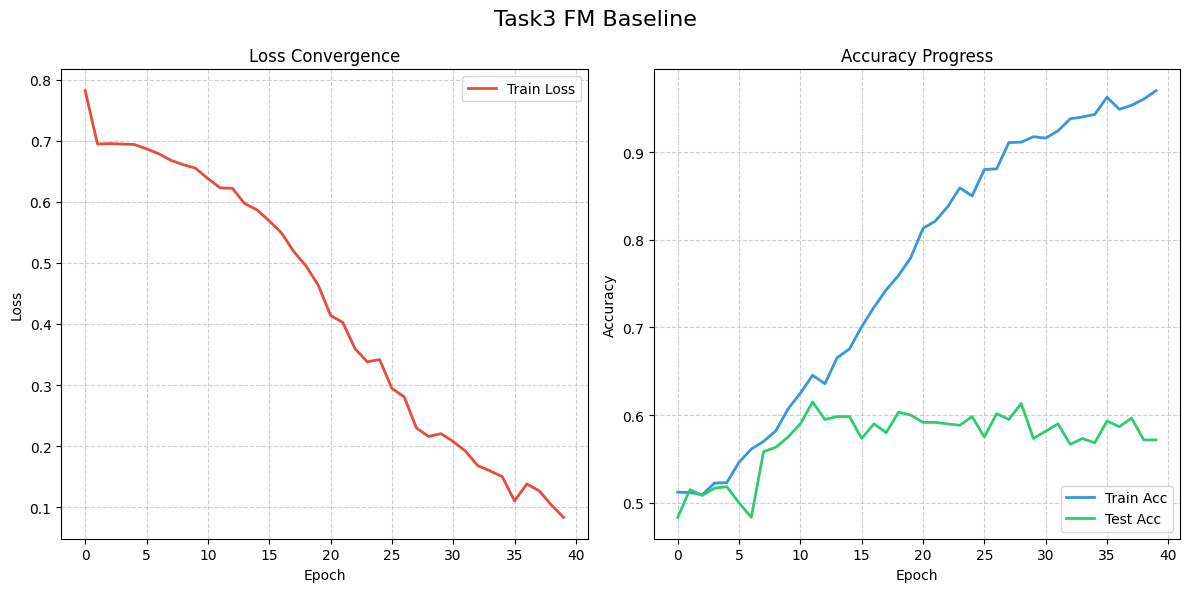

Epoch 40/40 | Loss 0.0834 | Train Acc 0.9700 | Test Acc 0.5717
Task 3 best test accuracy: 0.6150
Task 3 done.
FM best test acc: 0.6150


In [21]:
# Task 3 execution
# Requires: Task 1 outputs (X_prep, y)
fm_model, fm_hist, fm_best_acc = run_task3_train_fm_baseline(
    X_prep, y, epochs=40, batch_size=64, lr=1e-3
)
print('Task 3 done.')
print(f'FM best test acc: {fm_best_acc:.4f}')


In [15]:
# Task 3 model structure + how to deepen/widen Transformer
print('===== Task3 Model Structure =====')
print(fm_model)

print('===== How to deepen/widen the Transformer =====')
print('Deeper: increase num_layers in EEGFMBaseline(...)')
print('Wider:  increase d_model (and optionally dim_ff) in EEGFMBaseline(...)')
print('Where to change: in the EEGFMBaseline __init__ definition (Task3 definition cell).')
print('Example: EEGFMBaseline(num_channels=n_ch, seq_len=n_t, d_model=192, num_layers=6, dim_ff=512)')


===== Task3 Model Structure =====
EEGFMBaseline(
  (input_proj): Linear(in_features=64, out_features=128, bias=True)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (cls): Linear(in_features=128, out_features=2, bias=True)
)
===== How to deepen/widen the Transformer =====
Deep

In [13]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# Stronger Task-4 model: local temporal conv -> global sequence modeling -> attention pooling.
class AdvancedAADNet(nn.Module):
    """Task 4: stronger model than baselines (Conv + BiGRU + Attention)."""
    def __init__(self, num_channels=64, hidden=128, attn_heads=4):
        super().__init__()
        self.num_channels = num_channels

        self.temporal = nn.Sequential(
            nn.Conv1d(num_channels, hidden, kernel_size=7, padding=3),
            nn.BatchNorm1d(hidden),
            nn.GELU(),
            nn.Conv1d(hidden, hidden, kernel_size=5, padding=2),
            nn.BatchNorm1d(hidden),
            nn.GELU(),
        )

        self.bigru = nn.GRU(
            input_size=hidden,
            hidden_size=hidden // 2,
            num_layers=2,
            batch_first=True,
            dropout=0.2,
            bidirectional=True,
        )

        self.attn = nn.MultiheadAttention(embed_dim=hidden, num_heads=attn_heads, batch_first=True)
        self.cls = nn.Sequential(
            nn.LayerNorm(hidden),
            nn.Linear(hidden, 64),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(64, 2),
        )

    def _to_bct(self, x):
        if x.dim() != 3:
            raise ValueError(f'Expected 3D tensor, got {tuple(x.shape)}')
        if x.shape[1] == self.num_channels:
            return x
        if x.shape[2] == self.num_channels:
            return x.transpose(1, 2)
        raise ValueError(f'Cannot infer channel dimension from {tuple(x.shape)}')

    def forward(self, x):
        x = self._to_bct(x)        # (B, C, T)
        x = self.temporal(x)       # (B, H, T)
        x = x.transpose(1, 2)      # (B, T, H)
        x, _ = self.bigru(x)       # (B, T, H)
        x, _ = self.attn(x, x, x)  # (B, T, H)
        x = x.mean(dim=1)
        return self.cls(x)


def run_task4_train_advanced(
    X_prep,
    y,
    test_size=0.2,
    random_state=42,
    epochs=30,
    batch_size=64,
    lr=8e-4,
    weight_decay=1e-4,
):
    """Task 4: advanced model exploration and evaluation."""
    n_samples, n_ch, n_t = X_prep.shape
    X_flat = X_prep.reshape(n_samples, -1)

    X_train, X_test, y_train, y_test = train_test_split(
        X_flat,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y,
    )

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train).reshape(-1, n_ch, n_t)
    X_test = scaler.transform(X_test).reshape(-1, n_ch, n_t)

    train_ds = EEGDataset(X_train, y_train)
    test_ds = EEGDataset(X_test, y_test)
    # Use same split/protocol as Task 3 to keep comparison fair.
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    device = get_device()
    model = AdvancedAADNet(num_channels=n_ch).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss()

    best_acc = 0.0
    history = {'train_acc': [], 'test_acc': []}

    for epoch in range(1, epochs + 1):
        model.train()
        correct = total = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            correct += (logits.argmax(dim=1) == yb).sum().item()
            total += yb.size(0)
        train_acc = correct / max(1, total)

        model.eval()
        correct = total = 0
        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                correct += (logits.argmax(dim=1) == yb).sum().item()
                total += yb.size(0)
        test_acc = correct / max(1, total)

        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)
        best_acc = max(best_acc, test_acc)
        print(f"Epoch {epoch:02d}/{epochs} | Train Acc {train_acc:.4f} | Test Acc {test_acc:.4f}")

    print(f"Task 4 best test accuracy: {best_acc:.4f}")
    return model, history, best_acc


In [14]:
# Task 4 execution
# Requires: Task 1 outputs (X_prep, y)
adv_model, adv_hist, adv_best_acc = run_task4_train_advanced(
    X_prep, y, epochs=40, batch_size=64, lr=8e-4
)
print('Task 4 done.')
print(f'Advanced model best test acc: {adv_best_acc:.4f}')


Using device: mps
Epoch 01/40 | Train Acc 0.5238 | Test Acc 0.4933
Epoch 02/40 | Train Acc 0.5421 | Test Acc 0.5533
Epoch 03/40 | Train Acc 0.5633 | Test Acc 0.5517
Epoch 04/40 | Train Acc 0.5737 | Test Acc 0.5767
Epoch 05/40 | Train Acc 0.5767 | Test Acc 0.5683
Epoch 06/40 | Train Acc 0.5829 | Test Acc 0.5500
Epoch 07/40 | Train Acc 0.5733 | Test Acc 0.5850
Epoch 08/40 | Train Acc 0.5746 | Test Acc 0.5433
Epoch 09/40 | Train Acc 0.5854 | Test Acc 0.5717
Epoch 10/40 | Train Acc 0.5854 | Test Acc 0.5567
Epoch 11/40 | Train Acc 0.5942 | Test Acc 0.5867
Epoch 12/40 | Train Acc 0.5946 | Test Acc 0.5633
Epoch 13/40 | Train Acc 0.5979 | Test Acc 0.6050
Epoch 14/40 | Train Acc 0.6046 | Test Acc 0.5950
Epoch 15/40 | Train Acc 0.6046 | Test Acc 0.5750
Epoch 16/40 | Train Acc 0.6058 | Test Acc 0.5633
Epoch 17/40 | Train Acc 0.6162 | Test Acc 0.5767
Epoch 18/40 | Train Acc 0.6292 | Test Acc 0.5950
Epoch 19/40 | Train Acc 0.6479 | Test Acc 0.5850
Epoch 20/40 | Train Acc 0.6462 | Test Acc 0.6367
Ep